# 03 — XGBoost Demand Forecasting Model

Trains an XGBoost regressor on the engineered dataset (`smart_pharmacy_dataset_engineered.csv`) to predict `next_week_demand` for each medicine. Uses a **time-based split** rather than a random split, since this is sequential per-medicine data and a random split would let the model "see the future" during training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, r2_score
)

df = pd.read_csv("../Dataset/smart_pharmacy_dataset_engineered.csv")
df = df.sort_values(["medicine_id", "year", "week_number"]).reset_index(drop=True)
df.shape

(23400, 42)

## 1. Time-Based Train / Validation / Test Split

The dataset spans 2023–2025, 52 weeks per year per medicine.

- **Train**: 2023 (full year) + 2024 weeks 1–44
- **Validation**: 2024 weeks 45–52 — used only for early stopping, not for tuning decisions
- **Test**: 2025 (full year) — untouched holdout, evaluated once at the end

Splitting by calendar time (rather than randomly shuffling rows) means the model is never trained on a week and then asked to predict an earlier week — it mirrors how the model would actually be used in production.

In [2]:
train_mask = (df["year"] == 2023) | ((df["year"] == 2024) & (df["week_number"] <= 44))
val_mask = (df["year"] == 2024) & (df["week_number"] > 44)
test_mask = (df["year"] == 2025)

print(f"Train: {train_mask.sum()} rows")
print(f"Val:   {val_mask.sum()} rows")
print(f"Test:  {test_mask.sum()} rows")

Train: 14400 rows
Val:   1200 rows
Test:  7800 rows


## 2. Feature / Target Setup

Dropped from the feature set:
- `medicine_name` — redundant with `medicine_id`
- `medicine_importance` — the raw string; `medicine_importance_score` (the ordinal-encoded version from feature engineering) is used instead
- `next_week_demand` — the target

`medicine_id` is kept and cast to a pandas `category` dtype so XGBoost can split on it natively (each medicine has its own baseline demand level that isn't fully captured by `category`/`medicine_importance` alone).

In [3]:
drop_cols = ["medicine_name", "medicine_importance", "next_week_demand"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
X["medicine_id"] = X["medicine_id"].astype("category")
y = df["next_week_demand"]

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"{len(feature_cols)} features:")
print(feature_cols)

39 features:
['medicine_id', 'year', 'week_number', 'current_stock', 'previous_week_sales', 'sales_last_2_week', 'sales_last_4_week_average', 'flu_cases', 'dengue_cases', 'covid_cases', 'supplier_delivery_days', 'stock_received', 'expiry_risk', 'is_holiday_week', 'week_sin', 'week_cos', 'medicine_importance_score', 'cat_Antibiotic', 'cat_Cardiac', 'cat_Diabetes', 'cat_Emergency', 'cat_Fever/Pain Relief', 'cat_Gastrointestinal', 'cat_Respiratory', 'cat_Vitamin/Supplement', 'season_Monsoon', 'season_Normal', 'season_Summer', 'season_Winter', 'weeks_of_stock', 'stockout_flag', 'net_stock_flow', 'sales_trend_short', 'sales_trend_long', 'sales_acceleration', 'total_disease_burden', 'demand_lag_1', 'demand_lag_2', 'demand_rolling_std_4']


## 3. Train the Model

`tree_method="hist"` with `enable_categorical=True` lets XGBoost split on `medicine_id` natively without one-hot encoding 150 columns. Early stopping on the validation set prevents overfitting — training stops once validation RMSE hasn't improved for 50 rounds, and the model rolls back to the best iteration.

In [4]:
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_lambda=1.0,
    tree_method="hist",
    enable_categorical=True,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42,
)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print(f"Stopped at iteration {model.best_iteration} (of 1000 max)")

Stopped at iteration 250 (of 1000 max)


## 4. Evaluate on the Held-Out 2025 Test Year

Four metrics, each answering a different question:
- **RMSE** — typical error in units, penalizes large misses more
- **MAE** — typical error in units, treats all misses equally
- **MAPE** — typical error as a percentage, comparable across high- and low-volume medicines
- **R²** — share of demand variance the model explains

In [5]:
preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
mape = mean_absolute_percentage_error(y_test, preds) * 100
r2 = r2_score(y_test, preds)

print(f"RMSE: {rmse:.2f} units")
print(f"MAE:  {mae:.2f} units")
print(f"MAPE: {mape:.2f}%")
print(f"R2:   {r2:.4f}")

RMSE: 10.11 units
MAE:  6.12 units
MAPE: 11.71%
R2:   0.9337


## 5. Feature Importance

Which signals is the model actually leaning on?

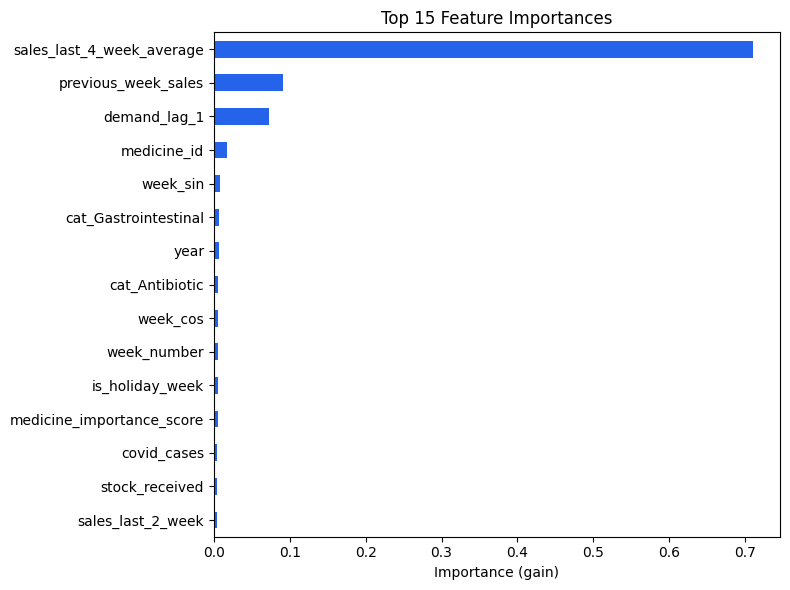

sales_last_4_week_average    0.710738
previous_week_sales          0.091215
demand_lag_1                 0.072137
medicine_id                  0.016705
week_sin                     0.007523
cat_Gastrointestinal         0.007254
year                         0.006733
cat_Antibiotic               0.005633
week_cos                     0.004960
week_number                  0.004924
is_holiday_week              0.004839
medicine_importance_score    0.004722
covid_cases                  0.004550
stock_received               0.004032
sales_last_2_week            0.003954
dtype: float32

In [6]:
importance = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importance.head(15).iloc[::-1].plot(kind="barh", ax=ax, color="#2563eb")
ax.set_xlabel("Importance (gain)")
ax.set_title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

importance.head(15)

**Note:** `sales_last_4_week_average` dominates, which matches what the feature engineering notebook flagged — it's the single strongest correlate of `next_week_demand` (0.95) because demand is highly autocorrelated. The engineered features (`demand_lag_1`, `week_sin`/`week_cos`, `medicine_id`, category dummies) contribute smaller, complementary signal on top of that baseline rather than driving the prediction outright.

## 6. Predicted vs. Actual

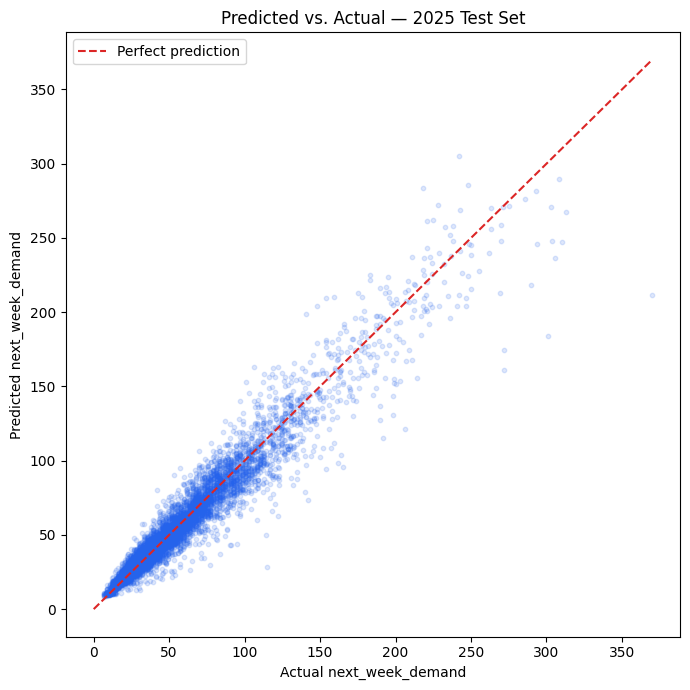

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, preds, alpha=0.15, s=10, color="#2563eb")
lims = [0, max(y_test.max(), preds.max())]
ax.plot(lims, lims, color="#dc2626", linestyle="--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual next_week_demand")
ax.set_ylabel("Predicted next_week_demand")
ax.set_title("Predicted vs. Actual — 2025 Test Set")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Business-Relevant Breakdown: Performance by Medicine Importance

Accuracy alone doesn't tell the full story for a stockout-prevention system — an under-prediction on a Critical medicine is far costlier than one on a Low-importance medicine. This checks MAPE and the **under-prediction rate** (how often the model predicts *less* than what was actually demanded — the direction of error that causes stockouts) per importance tier.

In [8]:
eval_df = df.loc[test_mask, ["medicine_importance"]].copy()
eval_df["actual"] = y_test.values
eval_df["predicted"] = preds
eval_df["under_predicted"] = eval_df["predicted"] < eval_df["actual"]

summary = eval_df.groupby("medicine_importance").apply(
    lambda g: pd.Series({
        "MAPE_%": mean_absolute_percentage_error(g["actual"], g["predicted"]) * 100,
        "pct_under_predicted": g["under_predicted"].mean() * 100,
        "n_weeks": len(g),
    }),
    include_groups=False,
).reindex(["Critical", "High", "Medium", "Low"])

summary

,MAPE_%,pct_under_predicted,n_weeks
medicine_importance,,,
Critical,12.783836,41.346154,1248.0
High,11.718036,47.061966,1872.0
Medium,11.365443,48.050214,3744.0
Low,11.613448,47.542735,936.0


If `pct_under_predicted` runs meaningfully above 50% for Critical/High tiers, the model is biased toward *under*-stocking the medicines where a stockout matters most — which would be worth correcting with a custom loss that penalizes under-prediction more heavily, or by adding a safety margin on top of the raw prediction for high-importance drugs.

## 8. Save the Model

In [9]:
model.save_model("../models/xgb_demand_model.json")
print("Model saved.")

Model saved.
